# Breve explicação sobre modelos de One-Class Novelty Detectiom

[Material de referência no Sidechannel](https://www.sidechannel.blog/fortalecendo-sistemas-de-deteccao-de-intrusao-com-machine-learning-parte-3-de-5/)


In [1]:
import numpy as np
import pandas as pd

import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm


from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix

In [2]:
from sklearn.decomposition import PCA

In [3]:
RANDOM_SEED = 33
np.random.seed(RANDOM_SEED)

# Carregando os dados

In [4]:
df_list = []
for file in os.listdir('data/CIC_IDS_2017/'):
  df_aux = pd.read_csv(f'data/CIC_IDS_2017/{file}')
  df_list.append(df_aux)
df = pd.concat(df_list, ignore_index=True)

Algumas colunas tem seus nomes iniciados com espaços ou finalizados com espaços. Vamos remover esses espaços não úteis para ajustar o nome das colunas.

In [5]:
df.columns = df.columns.str.strip()

In [6]:
df.shape

(2830743, 79)

In [7]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

# Limpando os dados

É necessário limpar os dados realizando:
- Descarte de registros duplicados
- Descarte de registros com valores NaN (Not a Number)/ Null / NA (Not Available)
- Evitar registros com valores não finitos. Nesse caso, uma abordagem válida é substituirmos os mesmos pelo maior valor finito presente no dataset.

Registros duplicados

In [8]:
# Descartando duplicadas
initial_len = df.shape[0]
df = df.drop_duplicates()
print(f'Tamanho inicial: {initial_len}, tamanho final {df.shape[0]} | Descartadas {initial_len - df.shape[0]} duplicadas')

Tamanho inicial: 2830743, tamanho final 2522362 | Descartadas 308381 duplicadas


Registros com valores Null/NaN/NA

In [9]:
# Descartando registros com valores NaN/Null/NA
initial_len = df.shape[0]
df = df.dropna()
print(f'Tamanho inicial: {initial_len}, tamanho final {df.shape[0]} | Descartados {initial_len - df.shape[0]} registros com valores NA')

Tamanho inicial: 2522362, tamanho final 2522009 | Descartados 353 registros com valores NA


In [10]:
df = df.reset_index(drop=True)

Registros com valores não finitos

In [11]:
# Evitando registros com valores não finitos
max_finite_flow_packets_per_sec = df[np.isfinite(df['Flow Packets/s'])]['Flow Packets/s'].max()
max_finite_flow_bytes_per_sec = df[np.isfinite(df['Flow Bytes/s'])]['Flow Bytes/s'].max()

df.loc[df['Flow Packets/s'] == np.inf, 'Flow Packets/s'] = max_finite_flow_packets_per_sec
df.loc[df['Flow Bytes/s'] == np.inf, 'Flow Bytes/s'] = max_finite_flow_bytes_per_sec

# Dividindo dados nos conjuntos de treino, validação e teste

**Conjunto de treino**

Para a detecção de anomalias, vamos usar somente os dados que representam o tráfego benigno para o conjunto de treino. Dessa forma, os algoritmos serão capazes de identificar padrões e desvios em relação ao comportamento normal (benigno) dos dados.

**Conjuntos de validação e teste**

Porém, devem ser incluídos dados que representam o tráfego maliciosos nos conjuntos de validação e teste. Esses dados maliciosos no conjunto de validação são importantes para que possamos definir um *threshold* para que seja possível detectar anomalias. Além disso, os dados maliciosos também precisam ser incluídos no conjunto de teste para que possamos avaliar o desempenho do nosso modelo.

In [12]:
df_train = df.query('Label == "BENIGN"').sample(frac=0.6, random_state=RANDOM_SEED)
df_val_test = df.drop(df_train.index)

df_train = df_train.reset_index(drop=True)
df_val_test = df_val_test.reset_index(drop=True)

X_train = df_train.drop('Label', axis='columns')

In [13]:
X_val, X_test, classes_val, classes_test = train_test_split(df_val_test.drop('Label', axis='columns'), df_val_test['Label'], test_size=0.65, stratify=df_val_test['Label'], random_state=RANDOM_SEED)

X_val, X_test = X_val.reset_index(drop=True), X_test.reset_index(drop=True)
classes_val, classes_test =  classes_val.reset_index(drop=True), classes_test.reset_index(drop=True)

y_val, y_test = classes_val.apply(lambda c: 0 if c == 'BENIGN' else 1), classes_test.apply(lambda c: 0 if c == 'BENIGN' else 1)

In [14]:
del df_train, df_val_test

#### Resultado da divisão dos conjuntos de dados
- Dados de treino: 60% do total de registros benignos
- Dados de validação: 14% do total de registros benignos + 35% do total de registros maliciosos
- Dados de teste: 26% do total de registros benignos + 65% do total de registros maliciosos

Queremos detectar anomalias, então vamos treinar o modelo apenas com os dados benignos. Dessa forma, o modelo será capaz de identificar padrões e desvios em relação ao comportamento normal (benigno) dos dados.

# Analisando correlação entre features

**Por que remover features?**

Vamos descartar features com alta correlação evitando passar informações redundantes ao modelo. Dessa forma, conseguiremos obter um modelo mais simples e com menor custo computacional.

In [15]:
def get_highly_correlated_features(correlation_matrix, threshold):
  correlated_pairs = []
  for i in range(len(correlation_matrix.columns)):
    for j in range(i):
      if abs(correlation_matrix.iloc[i, j]) > threshold:
        pair = (correlation_matrix.columns[i], correlation_matrix.columns[j])
        coefficient = correlation_matrix.iloc[i, j]
        correlated_pairs.append((pair, coefficient))
  return sorted(correlated_pairs, key= lambda pair: pair[1], reverse=True)


In [16]:
corr_matrix = X_train.corr().abs()
correlation_list = get_highly_correlated_features(corr_matrix, 0.95)

In [17]:
correlation_list[:10]

[(('SYN Flag Count', 'Fwd PSH Flags'), np.float64(1.0)),
 (('CWE Flag Count', 'Fwd URG Flags'), np.float64(1.0)),
 (('Avg Fwd Segment Size', 'Fwd Packet Length Mean'), np.float64(1.0)),
 (('Avg Bwd Segment Size', 'Bwd Packet Length Mean'), np.float64(1.0)),
 (('Fwd Header Length.1', 'Fwd Header Length'), np.float64(1.0)),
 (('Subflow Fwd Packets', 'Total Fwd Packets'), np.float64(1.0)),
 (('Subflow Fwd Bytes', 'Total Length of Fwd Packets'), np.float64(1.0)),
 (('Subflow Bwd Packets', 'Total Backward Packets'), np.float64(1.0)),
 (('Subflow Bwd Bytes', 'Total Length of Bwd Packets'),
  np.float64(0.9999998619402976)),
 (('Subflow Fwd Packets', 'Total Backward Packets'),
  np.float64(0.9991954734499192))]

In [18]:
# Drop high correlated features in correlation list

f2drop = []
for feature_pair, _ in correlation_list:
  if feature_pair[0] not in f2drop and feature_pair[1] not in f2drop:
    f2drop.append(feature_pair[1])

In [19]:
f2drop

['Fwd PSH Flags',
 'Fwd URG Flags',
 'Fwd Packet Length Mean',
 'Bwd Packet Length Mean',
 'Fwd Header Length',
 'Total Fwd Packets',
 'Total Length of Fwd Packets',
 'Total Backward Packets',
 'Total Length of Bwd Packets',
 'Subflow Fwd Packets',
 'Flow Duration',
 'RST Flag Count',
 'Subflow Bwd Packets',
 'Packet Length Mean',
 'Flow IAT Max',
 'Idle Mean',
 'Fwd IAT Total',
 'Fwd Packet Length Max',
 'Max Packet Length',
 'Bwd IAT Max',
 'Bwd IAT Mean',
 'Fwd IAT Max',
 'Fwd IAT Mean',
 'Idle Max']

A feature "Destination Port", também não fornece muita contribuição devido que a mesma está codificada com valores inteiros, indicando uma relação de grandeza, como 44720 > 80, que não apresenta sentido semântico quando se trata da porta de destino de um fluxo de rede.

In [20]:
f2drop = f2drop + ['Destination Port']

In [21]:
X_train = X_train.drop(f2drop, axis='columns')
X_val = X_val.drop(f2drop, axis='columns')
X_test = X_test.drop(f2drop, axis='columns')

# Normalizando os dados

É importante normalizar os dados para lidar com diferentes escalas, sensibilidades a escalas e até mesmo melhorar o desempenho da convergência dos algoritmos.

Caso não seja realizada a normalização, um valor de 10000 para uma feature como "Flow Bytes/s" terá impacto similar ao modelo quanto um valor de 10000 para uma feature como "Flow Packets/s". Isso é prejudicial, pois o impacto desse valor para as duas features deve ser tratado de forma distinta, já que as mesmas têm escalas e sensibilidades também distintas.

In [22]:
std_scaler = StandardScaler()
std_scaler = std_scaler.fit(X_train)

norm_X_train = std_scaler.transform(X_train)
norm_X_val = std_scaler.transform(X_val)
norm_X_test = std_scaler.transform(X_test)

In [23]:
del X_train, X_val, X_test

# Detecção de Anomalias com o Isolation Forest

In [24]:
from sklearn.ensemble import IsolationForest
N_ESTIMATORS = 100
model_iforest = IsolationForest(n_estimators = N_ESTIMATORS, random_state=RANDOM_SEED).fit(norm_X_train)

# Avaliando resultados

In [25]:
def plot_roc_curve(y_true, y_score, max_fpr=1.0):
  fpr, tpr, thresholds = roc_curve(y_true, y_score)
  aucroc = roc_auc_score(y_true, y_score)
  plt.plot(100*fpr[fpr < max_fpr], 100*tpr[fpr < max_fpr], label=f'ROC Curve (AUC = {aucroc:.4f})')
  plt.xlim(-2,102)
  plt.xlabel('FPR (%)')
  plt.ylabel('TPR (%)')
  plt.legend()
  plt.title('ROC Curve and AUCROC')

In [26]:
def get_tpr_per_attack(y_labels, y_pred):
  aux_df = pd.DataFrame({'Label':y_labels,'prediction':y_pred})
  total_per_label = aux_df['Label'].value_counts().to_dict()
  correct_predictions_per_label = aux_df.query('Label != "BENIGN" and prediction == True').groupby('Label').size().to_dict()
  tpr_per_attack = {}
  for attack_label, total in total_per_label.items():
    if attack_label == 'BENIGN':
      continue
    tp = correct_predictions_per_label[attack_label] if attack_label in correct_predictions_per_label else 0
    tpr = tp/total
    tpr_per_attack[attack_label] = tpr
  return tpr_per_attack

In [27]:
def get_overall_metrics(y_true, y_pred):
  tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
  acc = (tp+tn)/(tp+tn+fp+fn)
  tpr = tp/(tp+fn)
  fpr = fp/(fp+tn)
  precision = tp/(tp+fp)
  f1 = (2*tpr*precision)/(tpr+precision)
  return {'acc':acc,'tpr':tpr,'fpr':fpr,'precision':precision,'f1-score':f1}

In [28]:
def plot_confusion_matrix(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  group_counts = [f'{value:.0f}' for value in confusion_matrix(y_true, y_pred).ravel()]
  group_percentages = [f'{value*100:.2f}%' for value in confusion_matrix(y_true, y_pred).ravel()/np.sum(cm)]
  labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_counts, group_percentages)]
  labels = np.array(labels).reshape(2,2)
  sns.heatmap(cm, annot=labels, cmap='Oranges', xticklabels=['Predicted Benign', 'Predicted Malicious'], yticklabels=['Actual Benign', 'Actual Malicious'], fmt='')
  return

## Conjunto de validação

In [29]:
val_anomaly_preds = model_iforest.predict(norm_X_val)

In [30]:
val_anomaly_preds[val_anomaly_preds == 1] = 0
val_anomaly_preds[val_anomaly_preds == -1] = 1

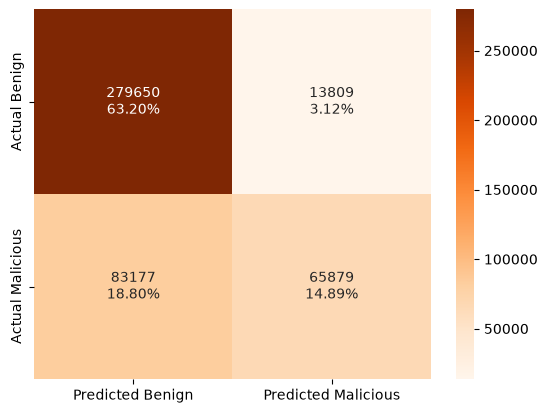

In [31]:
plot_confusion_matrix(y_val, val_anomaly_preds)

In [32]:
get_tpr_per_attack(classes_val, val_anomaly_preds)

{'DoS Hulk': 0.8380554086220576,
 'DDoS': 0.2654108824710976,
 'PortScan': 0.0015415106804668576,
 'DoS GoldenEye': 0.17888888888888888,
 'FTP-Patator': 0.0,
 'DoS slowloris': 0.563395225464191,
 'DoS Slowhttptest': 0.8049180327868852,
 'SSH-Patator': 0.0,
 'Bot': 0.02342606149341142,
 'Web Attack � Brute Force': 0.04474708171206226,
 'Web Attack � XSS': 0.02631578947368421,
 'Infiltration': 0.8461538461538461,
 'Web Attack � Sql Injection': 0.0,
 'Heartbleed': 1.0}

In [33]:
get_overall_metrics(y_val, val_anomaly_preds)

{'acc': np.float64(0.7808300283606205),
 'tpr': np.float64(0.44197482825246887),
 'fpr': np.float64(0.04705597715524145),
 'precision': np.float64(0.8267116755345849),
 'f1-score': np.float64(0.5760063651942783)}

## Conjunto de teste

In [34]:
test_anomaly_preds = model_iforest.predict(norm_X_test)

In [35]:
test_anomaly_preds[test_anomaly_preds == 1] = 0
test_anomaly_preds[test_anomaly_preds == -1] = 1

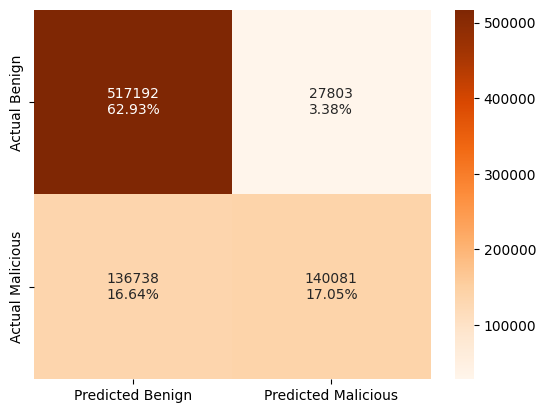

In [ ]:
plot_confusion_matrix(y_test, test_anomaly_preds)

In [ ]:
get_tpr_per_attack(classes_test, test_anomaly_preds)

{'DoS Hulk': 0.8676457498887405,
 'DDoS': 0.43471938468934024,
 'PortScan': 0.001761756335546822,
 'DoS GoldenEye': 0.2207597965898893,
 'FTP-Patator': 0.0,
 'DoS slowloris': 0.5542857142857143,
 'DoS Slowhttptest': 0.8343143025309006,
 'SSH-Patator': 0.0,
 'Bot': 0.02204724409448819,
 'Web Attack � Brute Force': 0.011506276150627616,
 'Web Attack � XSS': 0.02358490566037736,
 'Infiltration': 0.7391304347826086,
 'Web Attack � Sql Injection': 0.0,
 'Heartbleed': 1.0}

In [ ]:
get_overall_metrics(y_test, test_anomaly_preds)

{'acc': np.float64(0.7997831626134381),
 'tpr': np.float64(0.5060382415946882),
 'fpr': np.float64(0.05101514692795347),
 'precision': np.float64(0.8343916037263825),
 'f1-score': np.float64(0.6299979986642771)}

# Detecção de Anomalias com o One Class Support Vector Machine (OCSVM)

## Separando conjuntos

In [36]:
df = df.drop(f2drop, axis='columns')

In [37]:
# Train and val_test
X_train, X_val_test, classes_train, classes_val_test = train_test_split(df.drop('Label', axis='columns'), df['Label'], test_size=0.4, stratify=df['Label'], random_state=RANDOM_SEED)

X_train, X_val_test = X_train.reset_index(drop=True), X_val_test.reset_index(drop=True)
classes_train, classes_val_test =  classes_train.reset_index(drop=True), classes_val_test.reset_index(drop=True)

y_train = classes_train.apply(lambda c: 0 if c == 'BENIGN' else 1)

# Val and test
X_val, X_test, classes_val, classes_test = train_test_split(X_val_test, classes_val_test, test_size=0.6, stratify=classes_val_test, random_state=RANDOM_SEED)

X_val, X_test = X_val.reset_index(drop=True), X_test.reset_index(drop=True)
classes_val, classes_test =  classes_val.reset_index(drop=True), classes_test.reset_index(drop=True)

y_val, y_test = classes_val.apply(lambda c: 0 if c == 'BENIGN' else 1), classes_test.apply(lambda c: 0 if c == 'BENIGN' else 1)

In [38]:
std_scaler = StandardScaler()
std_scaler = std_scaler.fit(X_train)

norm_X_train = std_scaler.transform(X_train)
norm_X_val = std_scaler.transform(X_val)
norm_X_test = std_scaler.transform(X_test)

In [39]:
del X_train, X_val, X_test

**Resultado da divisão dos conjuntos de dados**

- 60% do total de registros para treino
- 16% do total de registros para validação
- 24% do total de registros para teste

Trabalhando com uma fração de cada um dos conjuntos para não estourar os limites de RAM do Colab

In [40]:
FRACTION = 0.02

random_train_indexes = np.random.choice(norm_X_train.shape[0], int(norm_X_train.shape[0]*FRACTION), replace=False)
norm_X_train_subset = norm_X_train[random_train_indexes,:]

random_val_indexes = np.random.choice(norm_X_val.shape[0], int(norm_X_val.shape[0]*FRACTION), replace=False)
norm_X_val_subset = norm_X_val[random_val_indexes,:]

random_test_indexes = np.random.choice(norm_X_test.shape[0], int(norm_X_test.shape[0]*FRACTION), replace=False)
norm_X_test_subset = norm_X_test[random_test_indexes,:]

In [41]:
y_train = y_train[random_train_indexes]
y_val = y_val[random_val_indexes]
y_test = y_test[random_test_indexes]

In [42]:
len(norm_X_train_subset), len(norm_X_val_subset), len(norm_X_test_subset)

(30264, 8070, 12105)

## Treino

In [43]:
from sklearn.svm import OneClassSVM

In [44]:
KERNEL = 'rbf'
NU = 0.1
GAMMA = 'scale'

model_ocsvm = OneClassSVM(nu=NU, kernel=KERNEL, gamma=GAMMA)

In [45]:
model_ocsvm = model_ocsvm.fit(norm_X_train_subset)

## Conjunto de validação

In [46]:
val_ocsvm_preds = model_ocsvm.predict(norm_X_val_subset)

In [47]:
val_ocsvm_preds[val_ocsvm_preds == 1] = 0
val_ocsvm_preds[val_ocsvm_preds == -1] = 1

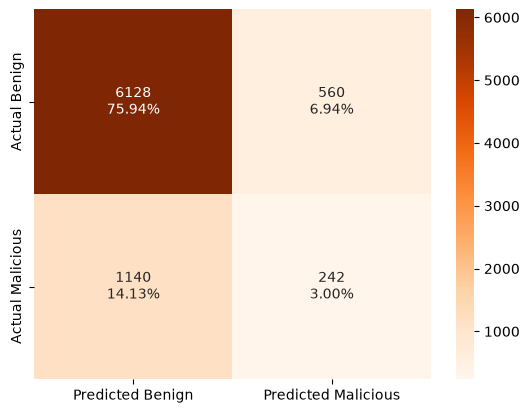

In [48]:
plot_confusion_matrix(y_val, val_ocsvm_preds)

In [49]:
get_tpr_per_attack(classes_val[random_val_indexes], val_ocsvm_preds)

{'DoS Hulk': 0.17597292724196278,
 'DDoS': 0.22493887530562348,
 'PortScan': 0.021505376344086023,
 'DoS GoldenEye': 0.358974358974359,
 'DoS Slowhttptest': 0.875,
 'FTP-Patator': 0.0,
 'DoS slowloris': 0.8571428571428571,
 'SSH-Patator': 0.0,
 'Web Attack � Brute Force': 0.0,
 'Bot': 0.0,
 'Web Attack � XSS': 0.0}

In [50]:
get_overall_metrics(y_val, val_ocsvm_preds)

{'acc': np.float64(0.7893432465923172),
 'tpr': np.float64(0.17510853835021709),
 'fpr': np.float64(0.08373205741626795),
 'precision': np.float64(0.30174563591022446),
 'f1-score': np.float64(0.22161172161172166)}

## Conjunto de teste

In [51]:
test_ocsvm_preds = model_ocsvm.predict(norm_X_test_subset)

In [52]:
test_ocsvm_preds[test_ocsvm_preds == 1] = 0
test_ocsvm_preds[test_ocsvm_preds == -1] = 1

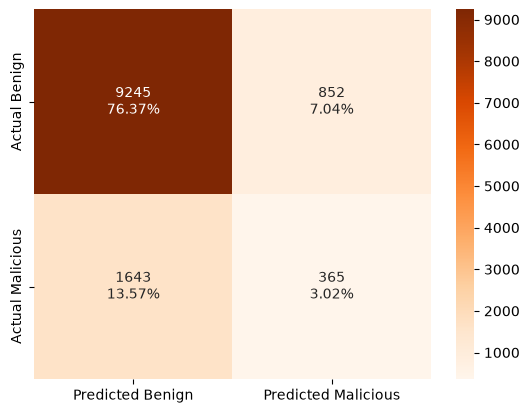

In [53]:
plot_confusion_matrix(y_test, test_ocsvm_preds)

In [54]:
get_tpr_per_attack(classes_test[random_test_indexes], test_ocsvm_preds)

{'DoS Hulk': 0.1912442396313364,
 'DDoS': 0.25,
 'PortScan': 0.01507537688442211,
 'DoS GoldenEye': 0.3,
 'DoS slowloris': 0.52,
 'FTP-Patator': 0.0,
 'DoS Slowhttptest': 0.9047619047619048,
 'SSH-Patator': 0.0,
 'Bot': 0.0,
 'Web Attack � Brute Force': 0.0}

In [55]:
get_overall_metrics(y_test, test_ocsvm_preds)

{'acc': np.float64(0.7938868236266006),
 'tpr': np.float64(0.18177290836653387),
 'fpr': np.float64(0.08438149945528375),
 'precision': np.float64(0.2999178307313065),
 'f1-score': np.float64(0.22635658914728682)}